# Faster R-CNN — Torchvision Challenger Model for Food Ingredient Detection

Trains a torchvision Faster R-CNN (ResNet-50-FPN-v2 backbone, COCO-pretrained) on the merged
FV40 + FOOD-INGREDIENTS food/ingredient detection dataset — a **challenger model** to the YOLO
model trained on the same unified taxonomy, so the two can be compared on the same test set
using the same metrics (mAP@0.5, mAP@[0.5:0.95]).

Data comes from `Data/merged_yolo/`: `train.txt`, `val.txt`, and `test.txt`, each listing one
absolute image path per line (images live in place under `fv40_merged/images/` or
`food_ingredients/<split>/images/` rather than being copied — see `food_image_merge.ipynb`).
Each image's YOLO-format label file (`class_id x_center y_center width height`, normalized 0-1,
one box per line) is resolved via the standard Ultralytics convention: swap the `images/` path
segment for `labels/` and the file extension for `.txt`.


## Training Reliability: Issues Encountered & Fixes

Getting this model to complete a single epoch on Colab took several rounds of diagnosis. This
section records what failed and why, since the workarounds in the cells below (archive-based data
staging, a stratified training subset, reduced input resolution, local checkpointing, flushed
per-batch logging) only make sense in that context.

**Issue 1 — kernel died mid-training (`notebook controller is DISPOSED`).**
Long-running cells ended with this VS Code/Jupyter error and no Python traceback, pointing at the
runtime/websocket connection dropping rather than a clean CUDA OOM or code error.
- Added mid-epoch checkpointing (every `CHECKPOINT_EVERY_N_BATCHES` batches) so a disconnect costs
  at most a few hundred batches instead of a full epoch.

**Issue 2 — a run went 281 minutes without completing one epoch, printing nothing.**
- Diagnosis: the split lists point at images on a mounted Drive Shared Drive, so each
  `__getitem__` opened two files over the Drive FUSE mount — tens of thousands of high-latency
  network reads per epoch.
- Fix: stage the data to local Colab disk (`/content/Data`) and read from there.

**Issue 3 — the staging fix reproduced the problem it was meant to solve.**
The first version used `shutil.copytree`, which copies file-by-file: the same ~27k high-latency
Drive reads, just paid up front. It never finished, so training never started.
- Fix: tar each directory into a single archive, cached on Drive and reused by later sessions, so
  each run does one large sequential read instead of thousands of small ones. Measured:
  `fv40_merged` took 1,643s to archive once, then **72s to copy + 33s to extract** thereafter.

**Issue 4 — two runs produced no output at all, which looked identical to a hang.**
- `print()` without `flush=True` is block-buffered on a remote/VS Code kernel transport, so
  progress lines sat in a buffer until the cell ended. Every training print now flushes, and the
  loop emits first-batch heartbeats either side of the forward/backward pass so a future stall
  localises to data loading vs GPU compute. In the successful run these fired at **0.3s** (first
  batch loaded) and **3.5s** (first optimizer step) — confirming neither was ever the bottleneck.

**Issue 5 — the archive build "failed" on a warning.**
`tar: food_ingredients/test: file changed as we read it` is GNU tar's *non-fatal* exit status 1
(2 is fatal), triggered because Drive's FUSE mount updates directory metadata while tar walks it.
The code treated any non-zero exit as failure and discarded a complete 0.70 GB archive, falling
back to streaming — which is why only `fv40_merged.tar` exists on Drive.
- Fix: accept exit 1 and print its warnings, but only after verifying the archive's end-of-archive
  marker (two 512-byte zero blocks). `tar -t` alone is *not* sufficient — a deliberately truncated
  archive listed 203 entries and exited 0 during testing, so the naive check would have cached a
  corrupt archive on Drive and silently trained on partial data.

**Issue 6 — resuming silently reinstated stale hyperparameters.**
`optimizer.load_state_dict` overwrites `param_groups['lr']`, so resuming a checkpoint written
before the LR change reinstated the old `lr=0.01` regardless of the configured value. `FRESH_START`
now defaults to `True`, and a resume prints the LR it actually restored.

**What the fixes bought.** The full 23,317-image split at torchvision's default 800/1333 resolution
was projected at roughly two hours per epoch — longer than a free Colab session survives. The
completed run instead sustained **10.2 img/s**, at **845–876s (~14 min) per epoch** including
validation, for **~2.4 hours total** across 10 epochs. Levers: 512/800 input resolution, a
stratified 32.5% training subset, and checkpoints written locally with only epoch-boundary syncs
to Drive.

**Also corrected:** `LR` was 0.01 at batch size 4 — twice what torchvision's reference recipe
(0.02 @ batch 16) scales to, and a divergence risk under fp16 AMP; it is now 0.005. And the model
section previously claimed only the new head was trained, but the printed counts show 43.8M of
44.0M parameters are trainable, since `trainable_backbone_layers` defaults to 3.

In [1]:
# Colab setup
from google.colab import drive
drive.mount('/content/drive')

!pip install torchmetrics pycocotools pyyaml -q


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.5 MB/s eta 0:00:00


In [2]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as TF

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from torchmetrics.detection.mean_ap import MeanAveragePrecision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Data & Class List

`classes.txt` (one name per line, in index order) or `data.yaml` (with a `names` field) is
expected directly inside `Data/merged_yolo/`, giving the same unified taxonomy the YOLO
challenger uses. Update `MERGED_YOLO_DIR` below if your Drive layout differs.


In [3]:
MERGED_YOLO_DIR = Path("/content/drive/Shareddrives/Computer Vision Final Project/Data/merged_yolo")

TRAIN_LIST = MERGED_YOLO_DIR / "train.txt"
VAL_LIST = MERGED_YOLO_DIR / "val.txt"
TEST_LIST = MERGED_YOLO_DIR / "test.txt"

assert TRAIN_LIST.exists(), (
    f"train.txt not found at {TRAIN_LIST} - update MERGED_YOLO_DIR to match your Drive layout."
)


def load_class_names(merged_dir: Path) -> list[str]:
    classes_txt = merged_dir / "classes.txt"
    if classes_txt.exists():
        return [line.strip() for line in classes_txt.read_text().splitlines() if line.strip()]

    data_yaml = merged_dir / "data.yaml"
    if data_yaml.exists():
        import yaml
        with open(data_yaml) as f:
            names = yaml.safe_load(f)["names"]
        return list(names.values()) if isinstance(names, dict) else list(names)

    raise FileNotFoundError(
        f"Neither classes.txt nor data.yaml found in {merged_dir} - add one, or edit "
        f"load_class_names() to point at wherever the class list actually lives."
    )


CLASS_NAMES = load_class_names(MERGED_YOLO_DIR)
# Faster R-CNN reserves label 0 for background, so raw (0-indexed) label-file class ids are
# shifted by +1 when building targets; CLASS_NAMES itself stays 0-indexed.
NUM_CLASSES = len(CLASS_NAMES) + 1

print(f"{len(CLASS_NAMES)} classes (+1 background) = {NUM_CLASSES} model outputs")
print(CLASS_NAMES)


148 classes (+1 background) = 149 model outputs
['akabare khursani', 'almond', 'apple', 'apricot', 'artichoke', 'ash gourd', 'asparagus', 'avocado', 'bacon', 'bamboo shoots', 'banana', 'beans', 'beaten rice', 'beef', 'beetroot', 'bell pepper', 'bethu ko saag', 'bitter gourd', 'black beans', 'black lentils', 'blackberry', 'blueberry', 'bottle gourd', 'bread', 'broad beans', 'broccoli', 'brussels sprouts', 'buff meat', 'butter', 'cabbage', 'cantaloup', 'carrot', 'cassava', 'cauliflower', 'cayenne', 'celery', 'chayote', 'cheese', 'cherry', 'chicken', 'chicken gizzards', 'chickpea', 'chili pepper', 'chili powder', 'chowmein noodles', 'cinnamon', 'citrus', 'clementine', 'coconut', 'coriander', 'corn', 'cornflakec', 'crab meat', 'cucumber', 'date', 'egg', 'eggplant', 'farsi ko munta', 'fiddlehead ferns', 'fig', 'fish', 'garden cress', 'garden peas', 'garlic', 'ginger', 'gourd', 'grape', 'green bean', 'green brinjal', 'green lentils', 'green mint', 'green onion', 'green peas', 'green soyabean

In [ ]:
import os
import shutil
import shlex
import subprocess


def image_to_label_path(image_path: Path) -> Path:
    """Swap the rightmost 'images' path segment for 'labels' and the extension for .txt."""
    parts = list(image_path.parts)
    try:
        idx = len(parts) - 1 - parts[::-1].index("images")
    except ValueError:
        raise ValueError(f"No 'images' path segment found in {image_path}")
    parts[idx] = "labels"
    return Path(*parts).with_suffix(".txt")


def load_image_list(list_path: Path) -> list[Path]:
    return [Path(line.strip()) for line in list_path.read_text().splitlines() if line.strip()]


# Staging data onto local Colab disk, via tar archives rather than a per-file copy.
#
# Reading images straight off the Drive FUSE mount makes each __getitem__ a pair of network file
# opens, so Drive's per-file latency - not GPU compute - sets the epoch time. Copying to /content
# fixes that, but a file-by-file `shutil.copytree` of ~27k images is itself slow enough to eat a
# whole Colab session. So: tar each directory into a single archive ONCE, kept on Drive and reused
# by every later session; each session then does one large sequential read (which Drive handles far
# better than thousands of small ones) plus a fast local extract.
#
# Robustness properties, all learned the hard way:
#   - Subprocess output is CAPTURED and printed. In Colab a subprocess writes to the kernel's
#     stderr, which does not appear in cell output, so a bare `check=True` surfaces only
#     "exit status 1" and throws away tar's actual explanation.
#   - GNU tar exit status 1 is NON-FATAL (2 is fatal). On a Drive FUSE mount, walking a directory
#     routinely trips "file changed as we read it" because Drive updates directory metadata as it
#     goes - the archive itself is fine. Treating exit 1 as failure discarded a complete 0.70 GB
#     archive, so exit 1 is now accepted and its warnings printed rather than swallowed.
#     (Suppressing it via --warning=no-file-changed is deliberately NOT used: that is a
#     GNU-tar-only option which hard-errors on other tar builds, and tolerating the exit status is
#     what actually matters. Showing the warnings is also more honest than hiding them.)
#   - Accepting exit 1 is only safe because a new archive is verified before the .partial is
#     renamed, so a genuinely truncated file can never be cached on Drive and trusted later.
#   - If the Drive archive cannot be built at all, staging falls back to streaming the data
#     straight from Drive to local disk with no intermediate archive - no Drive space, still fast.
DRIVE_DATA_ROOT = MERGED_YOLO_DIR.parent
LOCAL_DATA_ROOT = Path("/content/Data")
LOCAL_SCRATCH = LOCAL_DATA_ROOT.parent  # where archives land before being extracted
ARCHIVE_DIR = DRIVE_DATA_ROOT / "archives"

# GNU tar: 0 = clean, 1 = non-fatal difference/warning, 2 = fatal. Anything >= 2 is a real failure.
TAR_OK_RETURNCODES = (0, 1)

# Flip to True to let tar skip files it genuinely cannot read instead of aborting. Not needed for
# "file changed as we read it" (that is handled above) - this is for permission/IO errors, and it
# silently drops data, so check what got skipped.
TAR_IGNORE_READ_ERRORS = False


def free_gb(path) -> float:
    try:
        return shutil.disk_usage(path).free / 1e9
    except OSError:
        return float("nan")  # Drive FUSE does not always report usage


def run_capture(cmd, shell=False):
    """Run a command capturing output, so a failure is explained in the cell, not the kernel log."""
    return subprocess.run(cmd, shell=shell, capture_output=True, text=True)


def show_stderr(proc, prefix="    ") -> None:
    lines = (proc.stderr or "").strip().splitlines()
    if not lines:
        print(f"{prefix}(no stderr captured)")
        return
    print(f"{prefix}tar wrote {len(lines)} stderr line(s); first 20:")
    for line in lines[:20]:
        print(f"{prefix}  {line}")


def report_failure(proc, what: str) -> None:
    print(f"  FAILED: {what} (exit status {proc.returncode})")
    show_stderr(proc)


def tar_flags() -> list[str]:
    return ["--ignore-failed-read"] if TAR_IGNORE_READ_ERRORS else []


def has_end_of_archive_marker(archive: Path) -> bool:
    """A finished tar ends with at least two 512-byte zero blocks.

    This is the check that actually detects truncation. `tar -t` alone does NOT: given a truncated
    archive it happily lists every entry it can still reach and exits 0, which was verified against
    a deliberately truncated file. Only the end-of-archive marker distinguishes "complete" from
    "cut off partway through".
    """
    if archive.stat().st_size < 1024:
        return False
    with open(archive, "rb") as f:
        f.seek(-1024, os.SEEK_END)
        return f.read(1024) == b"\x00" * 1024


def verify_archive(archive: Path) -> bool:
    """Confirm a freshly built archive is complete and readable before it gets cached on Drive."""
    if not archive.exists():
        print(f"  {archive.name} was never created")
        return False

    if not has_end_of_archive_marker(archive):
        print(f"  {archive.name} has no end-of-archive marker - it is truncated")
        return False

    print(f"  verifying {archive.name} ...")
    start = time.time()
    proc = run_capture(["tar", "-tf", str(archive)])
    if proc.returncode not in TAR_OK_RETURNCODES:
        print(f"  archive failed verification (exit {proc.returncode})")
        show_stderr(proc)
        return False
    entries = len(proc.stdout.splitlines())
    print(f"  verified: {entries:,} entries, end-of-archive marker present ({time.time() - start:.0f}s)")
    return entries > 0


def build_drive_archive(subdir: str, archive: Path) -> bool:
    """Build the reusable archive on Drive. Returns False (without raising) if it fails."""
    partial = archive.with_suffix(".tar.partial")
    partial.unlink(missing_ok=True)  # stale leftover from an earlier failed build

    print(f"Building one-time archive {archive.name} on Drive (slow, but only happens once) ...")
    print(f"  free space - Drive: {free_gb(ARCHIVE_DIR):.1f} GB | local: {free_gb(LOCAL_SCRATCH):.1f} GB")
    cmd = ["tar", "-cf", str(partial), *tar_flags(), "-C", str(DRIVE_DATA_ROOT), subdir]

    start = time.time()
    proc = run_capture(cmd)
    if proc.returncode not in TAR_OK_RETURNCODES:
        report_failure(proc, f"building {archive.name}")
        if partial.exists():
            print(f"    discarding incomplete {partial.name} ({partial.stat().st_size / 1e9:.2f} GB)")
        partial.unlink(missing_ok=True)  # never leave a truncated archive a later run would trust
        return False

    if proc.returncode == 1:
        print(f"  tar exited 1 (non-fatal warnings) after {time.time() - start:.0f}s - "
              f"expected on a Drive mount, archive is still checked below:")
        show_stderr(proc, prefix="  ")

    if not verify_archive(partial):
        print(f"    discarding unverifiable {partial.name}")
        partial.unlink(missing_ok=True)
        return False

    partial.rename(archive)
    print(f"  built in {time.time() - start:.0f}s")
    return True


def extract_from_drive_archive(archive: Path, dst: Path) -> bool:
    size_gb = archive.stat().st_size / 1e9
    local_archive = LOCAL_SCRATCH / archive.name
    print(f"Copying {archive.name} ({size_gb:.2f} GB) from Drive -> local ...")
    start = time.time()
    shutil.copy2(archive, local_archive)
    print(f"  copied in {time.time() - start:.0f}s")

    # A cached archive can predate the truncation check, or have been copied badly - catch that
    # here rather than discovering missing images thousands of batches into an epoch.
    if not has_end_of_archive_marker(local_archive):
        print(f"  {archive.name} is truncated (no end-of-archive marker) - discarding the Drive copy")
        local_archive.unlink(missing_ok=True)
        archive.unlink(missing_ok=True)
        return False

    print(f"Extracting -> {dst} ...")
    start = time.time()
    proc = run_capture(["tar", "-xf", str(local_archive), "-C", str(LOCAL_DATA_ROOT)])
    local_archive.unlink(missing_ok=True)  # reclaim local disk; the Drive copy is the durable one
    if proc.returncode not in TAR_OK_RETURNCODES:
        report_failure(proc, f"extracting {archive.name}")
        return False
    print(f"  extracted in {time.time() - start:.0f}s")
    return True


def stream_drive_to_local(subdir: str) -> bool:
    """Fallback: pipe tar-create straight into tar-extract, writing nothing back to Drive."""
    print(f"Streaming {subdir} directly from Drive -> local (no Drive archive) ...")
    flags = " ".join(tar_flags())
    # `set -o pipefail` would surface a warning-level exit 1 from the producing tar as a pipeline
    # failure, so the producer's status is captured explicitly via PIPESTATUS and judged against
    # TAR_OK_RETURNCODES rather than being treated as fatal.
    pipeline = (
        f"tar -cf - {flags} -C {shlex.quote(str(DRIVE_DATA_ROOT))} {shlex.quote(subdir)} "
        f"| tar -xf - -C {shlex.quote(str(LOCAL_DATA_ROOT))}; "
        f"echo \"__STATUS__ ${{PIPESTATUS[0]}} $?\""
    )
    start = time.time()
    proc = run_capture(["bash", "-c", pipeline])

    status_line = [l for l in proc.stdout.splitlines() if l.startswith("__STATUS__")]
    if not status_line:
        report_failure(proc, f"streaming {subdir} (no status reported)")
        return False
    produce_rc, extract_rc = (int(x) for x in status_line[0].split()[1:3])
    if produce_rc not in TAR_OK_RETURNCODES or extract_rc not in TAR_OK_RETURNCODES:
        print(f"  FAILED: streaming {subdir} (produce exit {produce_rc}, extract exit {extract_rc})")
        show_stderr(proc)
        return False
    if produce_rc == 1 or extract_rc == 1:
        print("  tar exited 1 (non-fatal warnings):")
        show_stderr(proc, prefix="  ")
    print(f"  streamed in {time.time() - start:.0f}s")
    return True


def stage_subdir(subdir: str) -> None:
    src = DRIVE_DATA_ROOT / subdir
    dst = LOCAL_DATA_ROOT / subdir
    marker = dst / ".copy_complete"

    if not src.exists():
        print(f"{src} not found on Drive - skipping")
        return
    if marker.exists():
        print(f"{dst} already staged, skipping")
        return
    if dst.exists():
        shutil.rmtree(dst)  # partial extract from an interrupted run - start over
    LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

    ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)
    archive = ARCHIVE_DIR / f"{subdir}.tar"

    staged = False
    if archive.exists() or build_drive_archive(subdir, archive):
        staged = extract_from_drive_archive(archive, dst)
    if not staged:
        print(f"  Drive-archive path unavailable for {subdir} - falling back to direct streaming.")
        staged = stream_drive_to_local(subdir)

    if not staged:
        raise RuntimeError(
            f"Could not stage {subdir} to local disk - see the tar errors above. If they are "
            f"'No space left'/quota errors, free space on the Shared Drive (the archives/ folder "
            f"is a good candidate); if they are permission/IO errors on a few files, set "
            f"TAR_IGNORE_READ_ERRORS = True to skip them."
        )

    n_files = sum(1 for p in dst.rglob("*") if p.is_file())
    marker.touch()
    print(f"  {subdir} staged: {n_files:,} files under {dst}\n")


for subdir in ("fv40_merged", "food_ingredients"):
    stage_subdir(subdir)


def localize(path: Path) -> Path:
    return LOCAL_DATA_ROOT / path.relative_to(DRIVE_DATA_ROOT)


train_images = [localize(p) for p in load_image_list(TRAIN_LIST)]
val_images = [localize(p) for p in load_image_list(VAL_LIST)]
test_images = [localize(p) for p in load_image_list(TEST_LIST)]

print(f"train: {len(train_images):,} images | val: {len(val_images):,} | test: {len(test_images):,}")

# Fail loudly here rather than 5,000 batches into an epoch: confirm the staged files actually
# match what the split lists expect.
sampled = train_images[:200] + val_images[:50] + test_images[:50]
missing = [p for p in sampled if not p.exists()]
if missing:
    print(f"\nWARNING - {len(missing)}/{len(sampled)} sampled paths are missing locally, e.g.:")
    for p in missing[:5]:
        print(f"  {p}")
    print("Staging may be incomplete - check the tar output above.")
else:
    print(f"All {len(sampled)} sampled split paths resolve locally.")

# Sanity check the label-path convention against the first training entry
sample_img = train_images[0]
sample_label = image_to_label_path(sample_img)
print(f"\nSample image: {sample_img}")
print(f"Resolved label path: {sample_label}")
print(f"Label exists: {sample_label.exists()}")

## Training Subset (Compute Budget)

Faster R-CNN R50-FPN-v2 on a Colab T4 could not cover the full 23,317-image training split within a
session at torchvision's default resolution — the projection was roughly two hours per epoch. The
challenger is therefore trained on a **stratified subset** of the training split.

The property that keeps the comparison fair: **only `train` is subsampled — `val` and `test` stay
whole**, so `mAP@0.5` and `mAP@[0.5:0.95]` are computed over exactly the same held-out images the
YOLO model is scored on.

Stratification assigns each image to the **rarest class it contains** (background-only images get
their own stratum), samples `TRAIN_SUBSET_FRAC` within each stratum, and keeps *all* images from
strata smaller than `RARE_STRATUM_KEEP_ALL`. Uniform random sampling would drop most of this
dataset's long tail; this thins the head of the distribution instead.

**Measured result:** 7,578 of 23,317 images (32.5% — above the nominal 30% because 47 rare strata
were kept whole), retaining **146 of 146** classes present in the training split. No class was lost
to subsampling. At that size an epoch took ~14 minutes including validation.

Set `TRAIN_SUBSET_FRAC = 1.0` to train on everything given a longer-lived runtime.

In [5]:
from collections import Counter, defaultdict

TRAIN_SUBSET_FRAC = 0.30   # fraction of each stratum to keep; 1.0 disables subsetting entirely
RARE_STRATUM_KEEP_ALL = 40  # strata with at most this many images are kept in full


def read_class_ids(label_path: Path) -> set[int]:
    """Class ids present in a YOLO label file; empty set for missing/empty (background) files."""
    if not label_path.exists():
        return set()
    ids = set()
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) >= 5:
            ids.add(int(parts[0]))
    return ids


train_images_full = train_images  # keep the unsubsetted list around for reference/reporting

if TRAIN_SUBSET_FRAC >= 1.0:
    print(f"TRAIN_SUBSET_FRAC={TRAIN_SUBSET_FRAC} - using all {len(train_images_full):,} training images")
else:
    print(f"Scanning {len(train_images_full):,} training label files ...")
    start = time.time()
    image_class_ids = [read_class_ids(image_to_label_path(p)) for p in train_images_full]
    print(f"  done in {time.time() - start:.0f}s")

    # Global class frequency drives which class counts as "rarest" for stratum assignment.
    class_counts = Counter(cid for ids in image_class_ids for cid in ids)

    strata = defaultdict(list)
    for path, ids in zip(train_images_full, image_class_ids):
        # Anchoring on the rarest present class means an image is only ever counted toward the
        # class most at risk of disappearing from the subset.
        stratum = min(ids, key=lambda c: (class_counts[c], c)) if ids else "__background__"
        strata[stratum].append(path)

    rng = random.Random(SEED)  # own RNG so the subset is stable regardless of other random() calls
    subset = []
    kept_whole = 0
    for stratum in sorted(strata, key=str):
        members = sorted(strata[stratum])  # sort first so sampling doesn't depend on file order
        if len(members) <= RARE_STRATUM_KEEP_ALL:
            subset.extend(members)
            kept_whole += 1
        else:
            k = max(1, round(TRAIN_SUBSET_FRAC * len(members)))
            subset.extend(rng.sample(members, k))

    rng.shuffle(subset)
    train_images = subset

    # Class coverage in the chosen subset (cheap - labels are already parsed).
    ids_by_path = dict(zip(train_images_full, image_class_ids))
    subset_class_counts = Counter(cid for p in train_images for cid in ids_by_path[p])

    print(f"\nStratified subset: {len(train_images):,} / {len(train_images_full):,} images "
          f"({len(train_images) / len(train_images_full):.1%})")
    print(f"  {len(strata)} strata, {kept_whole} kept in full (<= {RARE_STRATUM_KEEP_ALL} images)")
    print(f"  class coverage: {len(subset_class_counts)} / {len(class_counts)} classes still present")
    missing = sorted(set(class_counts) - set(subset_class_counts))
    if missing:
        print(f"  WARNING - classes dropped entirely: {[CLASS_NAMES[c] for c in missing]}")


Scanning 23,317 training label files ...
  done in 1s

Stratified subset: 7,578 / 23,317 images (32.5%)
  147 strata, 47 kept in full (<= 40 images)
  class coverage: 146 / 146 classes still present


## Dataset

Converts each image's YOLO-normalized boxes into the pixel-space `[x1, y1, x2, y2]` format and
1-indexed labels Faster R-CNN expects. Images with no label file (or an empty one) are kept as
background images with zero boxes rather than dropped, matching how the EDA notebook treated
FOOD-INGREDIENTS background images.


In [6]:
class YoloDetectionDataset(Dataset):
    def __init__(self, image_paths: list[Path], train: bool = False):
        self.image_paths = image_paths
        self.train = train

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        boxes, labels = [], []
        label_path = image_to_label_path(img_path)
        if label_path.exists():
            for line in label_path.read_text().splitlines():
                parts = line.split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = min(max((xc - bw / 2) * w, 0), w)
                y1 = min(max((yc - bh / 2) * h, 0), h)
                x2 = min(max((xc + bw / 2) * w, 0), w)
                y2 = min(max((yc + bh / 2) * h, 0), h)
                # Clamping to image bounds (or a tiny/degenerate label box) can leave zero
                # width/height, which torchvision's RCNN forward pass rejects outright.
                if x2 - x1 <= 0 or y2 - y1 <= 0:
                    continue
                boxes.append([x1, y1, x2, y2])
                labels.append(cls_id + 1)  # shift so 0 stays reserved for background

        if self.train and boxes and random.random() < 0.5:
            img = TF.hflip(img)
            boxes = [[w - x2, y1, w - x1, y2] for x1, y1, x2, y2 in boxes]

        boxes_t = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels_t = torch.as_tensor(labels, dtype=torch.int64)
        area = (boxes_t[:, 2] - boxes_t[:, 0]) * (boxes_t[:, 3] - boxes_t[:, 1])

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
        }

        return TF.to_tensor(img), target


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = YoloDetectionDataset(train_images, train=True)
val_dataset = YoloDetectionDataset(val_images, train=False)
test_dataset = YoloDetectionDataset(test_images, train=False)

print(f"train: {len(train_dataset):,} | val: {len(val_dataset):,} | test: {len(test_dataset):,}")


train: 7,578 | val: 1,972 | test: 1,902


`BATCH_SIZE` is set for mixed-precision training on a Colab T4 — drop it back to 2 if you hit
CUDA OOM (AMP roughly halves activation memory vs. full FP32, so 4 is a reasonable starting point).
At the reduced 512/800 input resolution there is usually headroom to raise it to 8, which improves
GPU utilization — but scale `LR` linearly with it if you do (8 → 0.01).

`NUM_WORKERS=2` overlaps data loading with GPU compute, matching the 2 vCPUs a Colab T4 runtime
provides. This is safe now that images/labels are read from local disk (see the archive staging
step above) instead of the Drive mount — it was temporarily dropped to 0 while diagnosing a
multi-hour stall that turned out to be Drive I/O latency, not worker crashes.

In [7]:
BATCH_SIZE = 4
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)

## Model

`fasterrcnn_resnet50_fpn_v2` pretrained on COCO, with its box predictor replaced by one sized to
`NUM_CLASSES` (unified taxonomy + background).

Two things worth being precise about:

**What actually trains.** torchvision's `trainable_backbone_layers` defaults to 3 for a pretrained
model, which freezes only the ResNet stem and `layer1` — about 225k of 44.0M parameters. So this
is *not* a frozen-backbone / head-only setup: `layer2`–`layer4`, the FPN, the RPN, and both heads
all receive gradients (the printed `trainable` count below confirms it). That's the standard
detection fine-tuning recipe and generally the better-performing one, but it does mean the
backward pass costs nearly as much as training from scratch would. Passing
`trainable_backbone_layers=1` to the builder is an available speed lever if needed.

**Input resolution.** `min_size` / `max_size` are dropped from torchvision's 800/1333 defaults to
512/800. Convolutional cost scales with pixel count, so this is roughly a 2× throughput gain for a
modest accuracy cost — mostly on the smallest objects, which is worth noting when reading the
per-class AP table against the EDA notebook's box-size findings.

In [8]:
MIN_SIZE = 512   # torchvision default is 800
MAX_SIZE = 800   # torchvision default is 1333


def build_model(num_classes, min_size=MIN_SIZE, max_size=MAX_SIZE):
    # min_size/max_size are forwarded to the model's GeneralizedRCNNTransform, which rescales
    # every image so the shorter side is min_size (capped at max_size on the longer side).
    # Backbone/FPN/RPN cost scales with pixel count, so 512/800 instead of the default 800/1333
    # is roughly a 2x speedup - the single biggest lever short of changing the backbone.
    model = fasterrcnn_resnet50_fpn_v2(
        weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
        min_size=min_size,
        max_size=max_size,
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = build_model(NUM_CLASSES).to(device)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model built: {total:,} parameters ({trainable:,} trainable)")
print(f"Input resolution: min_size={MIN_SIZE}, max_size={MAX_SIZE}")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 176MB/s]


Model built: 44,009,528 parameters (43,784,184 trainable)
Input resolution: min_size=512, max_size=800


## Training Loop

Checkpoints after every epoch, so training can be split across sessions: stop the runtime whenever
you want and re-run the two cells below (with `FRESH_START = False`) to pick up where you left off.
`NUM_EPOCHS` is the *total* target epoch count, not "epochs from now."

**Read the results below with two caveats in mind.**

*Validation loss bottomed out at epoch 4* (0.8339) and never improved across epochs 5–10, which
ended at 0.8540 while training loss kept falling from 0.579 to 0.499 — textbook overfitting. The
evaluated checkpoint is therefore the epoch-4 model, which is correct, but roughly 1.4 of the 2.4
hours went into epochs that produced nothing. Early stopping on val loss (patience ~2) is the
obvious addition.

*The LR schedule decays too aggressively for a 10-epoch budget.* `StepLR(step_size=3, gamma=0.1)`
gives lr=0.005 for epochs 1–3, 0.0005 for 4–6, 0.00005 for 7–9, and 0.000005 for epoch 10 — by
epoch 7 the learning rate is 1/100th of base, which is why training loss flatlines at ~0.50 for the
last four epochs. Only about six epochs did meaningful work. A cosine schedule, or `step_size=4`–`5`,
would use the same budget far better and is the first thing to change on a re-run.

In [9]:
NUM_EPOCHS = 10  # total target epochs across all resumes, not "epochs from here"
# torchvision's reference Faster R-CNN recipe is lr=0.02 at batch size 16, and the linear scaling
# rule puts batch size 4 at 0.02 * 4/16 = 0.005. An earlier 0.01 here was 2x that, which combined
# with fp16 AMP is a well-known route to a diverging/NaN loss a few hundred batches in.
LR = 0.005
CHECKPOINT_EVERY_N_BATCHES = 250  # mid-epoch checkpoint interval - these are local writes now, so cheap
PRINT_EVERY_N_BATCHES = 50  # throughput/loss logging interval, so a stall is visible within minutes
VAL_PRINT_EVERY_N_BATCHES = 100  # the val pass is several silent minutes otherwise

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=LR, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# T4's fp16 tensor cores are ~8x its fp32 throughput, so autocast + GradScaler is the single
# biggest speed lever here. Only enabled on CUDA - autocast on CPU would silently do nothing
# useful and GradScaler requires a CUDA tensor.
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler(device.type) if use_amp else None


# Every print in the training path uses flush=True. Without it, stdout from a long-running cell is
# block-buffered on some kernel transports (notably VS Code driving a remote/Colab kernel), so
# progress lines sit in a buffer until the cell ends - which is indistinguishable from a hang, and
# is exactly the failure mode that made two earlier runs look stalled with no output at all.
def log(msg):
    print(msg, flush=True)


def train_one_epoch(model, loader, optimizer, device, scaler,
                     checkpoint_fn=None, checkpoint_every=None, print_every=None):
    model.train()
    running_loss = 0.0
    epoch_start = time.time()
    log(f"  epoch start: {len(loader):,} batches x {loader.batch_size} images "
        f"({len(loader.dataset):,} total), num_workers={loader.num_workers}")

    for batch_idx, (images, targets) in enumerate(loader):
        # Two heartbeats on the first batch, to localise a stall rather than guess at it: the first
        # fires once the DataLoader has actually produced data (so a hang before it means worker
        # startup or file reads), the second once a full forward+backward+step has completed (so a
        # hang between them means GPU compute).
        if batch_idx == 0:
            log(f"  [heartbeat] first batch loaded at {time.time() - epoch_start:.1f}s")

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=scaler is not None):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()

        if batch_idx == 0:
            log(f"  [heartbeat] first optimizer step done at {time.time() - epoch_start:.1f}s "
                f"- loss {loss.item():.4f}")

        if print_every and (batch_idx + 1) % print_every == 0:
            elapsed = time.time() - epoch_start
            imgs_per_sec = (batch_idx + 1) * loader.batch_size / elapsed
            eta_min = (len(loader) - batch_idx - 1) * elapsed / (batch_idx + 1) / 60
            log(f"  batch {batch_idx + 1}/{len(loader)} - avg_loss: {running_loss / (batch_idx + 1):.4f} "
                f"- {imgs_per_sec:.2f} img/s - {elapsed:.0f}s elapsed - ~{eta_min:.0f} min left this epoch")

        if checkpoint_fn is not None and checkpoint_every and (batch_idx + 1) % checkpoint_every == 0:
            checkpoint_fn()

    return running_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, device, scaler, print_every=None):
    """Faster R-CNN only returns losses in train() mode, so this switches modes just to compute
    a comparable validation loss - no gradients are taken since it runs under no_grad()."""
    model.train()
    running_loss = 0.0
    start = time.time()
    log(f"  validating on {len(loader.dataset):,} images ({len(loader):,} batches) ...")
    for batch_idx, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=scaler is not None):
            loss_dict = model(images, targets)
        running_loss += sum(loss_dict.values()).item()

        if print_every and (batch_idx + 1) % print_every == 0:
            log(f"    val batch {batch_idx + 1}/{len(loader)} - {time.time() - start:.0f}s elapsed")

    return running_loss / len(loader)

In [10]:
# Checkpoints are ~350 MB (44M params of weights + an equal-sized SGD momentum buffer). Writing
# that straight to the Drive FUSE mount every CHECKPOINT_EVERY_N_BATCHES batches stalled training
# for minutes at a time, so saves now go to local disk and are *synced* to Drive only at epoch
# boundaries. /content is wiped on a runtime reset, so the Drive copy is still what makes resuming
# across sessions possible - it just costs a fraction as many writes.
LOCAL_CHECKPOINT_DIR = Path("/content/checkpoints/fasterrcnn")
DRIVE_CHECKPOINT_DIR = MERGED_YOLO_DIR.parent / "checkpoints" / "fasterrcnn"
LOCAL_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RESUME_NAME = "fasterrcnn_resume.pt"
BEST_NAME = "fasterrcnn_best.pt"
LAST_NAME = "fasterrcnn_last.pt"


def resolve_checkpoint(name: str) -> Path | None:
    """Prefer the local copy (same session, always at least as fresh); fall back to Drive."""
    local = LOCAL_CHECKPOINT_DIR / name
    if local.exists():
        return local
    drive_path = DRIVE_CHECKPOINT_DIR / name
    return drive_path if drive_path.exists() else None


def sync_to_drive(name: str) -> None:
    src = LOCAL_CHECKPOINT_DIR / name
    if not src.exists():
        return
    start = time.time()
    shutil.copy2(src, DRIVE_CHECKPOINT_DIR / name)
    log(f"  [synced {name} to Drive in {time.time() - start:.0f}s]")


# Set True to ignore any existing checkpoint and train from COCO-pretrained weights.
#
# This matters more than it looks. A checkpoint carries optimizer state, and
# `optimizer.load_state_dict` overwrites the learning rate in `param_groups` with whatever the
# checkpoint held - so resuming from a run made under different settings silently reinstates that
# run's LR, defeating the `LR` set above. Any checkpoint written before the resolution/LR/subset
# changes is also weights trained on a different input size and a different data distribution.
# Mixing those into a fresh configuration produces a model that is hard to describe honestly in a
# writeup, so start clean whenever the training configuration changes.
FRESH_START = True

history = []
best_val_loss = float("inf")
start_epoch = 0

# Resuming picks up model/optimizer/scheduler/scaler state as of the last checkpoint - either a
# completed epoch or a mid-epoch save (see CHECKPOINT_EVERY_N_BATCHES above). A mid-epoch
# checkpoint stores the epoch it was taken *during* (not epoch + 1), so resuming re-runs that
# epoch's dataloader from the start with the partially-trained weights already loaded - some
# already-seen batches get repeated, but a disconnect never costs more than one epoch's worth of
# progress minus whatever was already checkpointed.
resume_path = None if FRESH_START else resolve_checkpoint(RESUME_NAME)

if FRESH_START:
    stale = resolve_checkpoint(RESUME_NAME)
    if stale is not None:
        print(f"FRESH_START=True - ignoring existing checkpoint at {stale}")
        print("  (set FRESH_START=False to resume it instead; delete the file to stop it lingering)")
    print("Training from COCO-pretrained weights.")
elif resume_path is not None:
    print(f"Loading resume checkpoint from {resume_path}")
    resume_ckpt = torch.load(resume_path, map_location=device)
    model.load_state_dict(resume_ckpt["model"])
    optimizer.load_state_dict(resume_ckpt["optimizer"])
    lr_scheduler.load_state_dict(resume_ckpt["lr_scheduler"])
    if use_amp and resume_ckpt.get("scaler") is not None:
        scaler.load_state_dict(resume_ckpt["scaler"])
    start_epoch = resume_ckpt["epoch"]
    best_val_loss = resume_ckpt["best_val_loss"]
    history = resume_ckpt["history"]

    # Report the LR the checkpoint actually restored, rather than letting it differ from `LR`
    # silently. A mismatch is expected after a StepLR decay; it is a problem if the checkpoint
    # predates a deliberate LR change.
    resumed_lr = optimizer.param_groups[0]["lr"]
    print(f"Resuming from epoch {start_epoch + 1} (best_val_loss so far: {best_val_loss:.4f})")
    print(f"  effective LR from checkpoint: {resumed_lr} (configured LR = {LR})")
    if resumed_lr != LR:
        print(f"  NOTE - restored LR differs from the configured {LR}. If that is a stale value "
              f"rather than a scheduler decay, set FRESH_START=True.")
else:
    print("No checkpoint found - training from COCO-pretrained weights.")

if start_epoch >= NUM_EPOCHS:
    print(f"Already trained through epoch {start_epoch}/{NUM_EPOCHS} - raise NUM_EPOCHS to train further.")


def save_checkpoint(epoch_for_resume, to_drive=False):
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "lr_scheduler": lr_scheduler.state_dict(),
        "scaler": scaler.state_dict() if use_amp else None,
        "epoch": epoch_for_resume,
        "best_val_loss": best_val_loss,
        "history": history,
    }, LOCAL_CHECKPOINT_DIR / RESUME_NAME)
    log(f"  [checkpoint saved locally - resume epoch {epoch_for_resume}]")
    if to_drive:
        sync_to_drive(RESUME_NAME)


for epoch in range(start_epoch, NUM_EPOCHS):
    start = time.time()
    log(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    train_loss = train_one_epoch(
        model, train_loader, optimizer, device, scaler,
        checkpoint_fn=lambda: save_checkpoint(epoch),  # mid-epoch: local only
        checkpoint_every=CHECKPOINT_EVERY_N_BATCHES,
        print_every=PRINT_EVERY_N_BATCHES,
    )
    val_loss = evaluate_loss(model, val_loader, device, scaler,
                             print_every=VAL_PRINT_EVERY_N_BATCHES)
    lr_scheduler.step()
    elapsed = time.time() - start

    history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss, "seconds": elapsed})
    log(f"Epoch {epoch + 1}/{NUM_EPOCHS} done - train_loss: {train_loss:.4f} "
        f"- val_loss: {val_loss:.4f} - {elapsed:.0f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), LOCAL_CHECKPOINT_DIR / BEST_NAME)
        sync_to_drive(BEST_NAME)

    save_checkpoint(epoch + 1, to_drive=True)  # epoch boundary: push to Drive so a reset is survivable

torch.save(model.state_dict(), LOCAL_CHECKPOINT_DIR / LAST_NAME)
sync_to_drive(LAST_NAME)
history_df = pd.DataFrame(history)
history_df

FRESH_START=True - ignoring existing checkpoint at /content/drive/Shareddrives/Computer Vision Final Project/Data/checkpoints/fasterrcnn/fasterrcnn_resume.pt
  (set FRESH_START=False to resume it instead; delete the file to stop it lingering)
Training from COCO-pretrained weights.

Epoch 1/10
  epoch start: 1,895 batches x 4 images (7,578 total), num_workers=2
  [heartbeat] first batch loaded at 0.3s
  [heartbeat] first optimizer step done at 3.5s - loss 6.1280
  batch 50/1895 - avg_loss: 1.7392 - 8.22 img/s - 24s elapsed - ~15 min left this epoch
  batch 100/1895 - avg_loss: 1.4455 - 9.43 img/s - 42s elapsed - ~13 min left this epoch
  batch 150/1895 - avg_loss: 1.3513 - 9.54 img/s - 63s elapsed - ~12 min left this epoch
  batch 200/1895 - avg_loss: 1.2435 - 9.91 img/s - 81s elapsed - ~11 min left this epoch
  batch 250/1895 - avg_loss: 1.1987 - 10.13 img/s - 99s elapsed - ~11 min left this epoch
  [checkpoint saved locally - resume epoch 0]
  batch 300/1895 - avg_loss: 1.1559 - 10.10

,epoch,train_loss,val_loss,seconds
0,1,0.922928,0.962261,845.274441
1,2,0.750806,0.907257,865.609371
2,3,0.689958,0.903737,862.173546
3,4,0.579076,0.833865,864.187918
4,5,0.546483,0.858814,861.686010
5,6,0.529200,0.844912,848.751873
6,7,0.507845,0.847813,845.476769
7,8,0.503795,0.853151,875.606553
8,9,0.502585,0.851797,854.392648
9,10,0.499307,0.854001,851.278688


### Training Curves


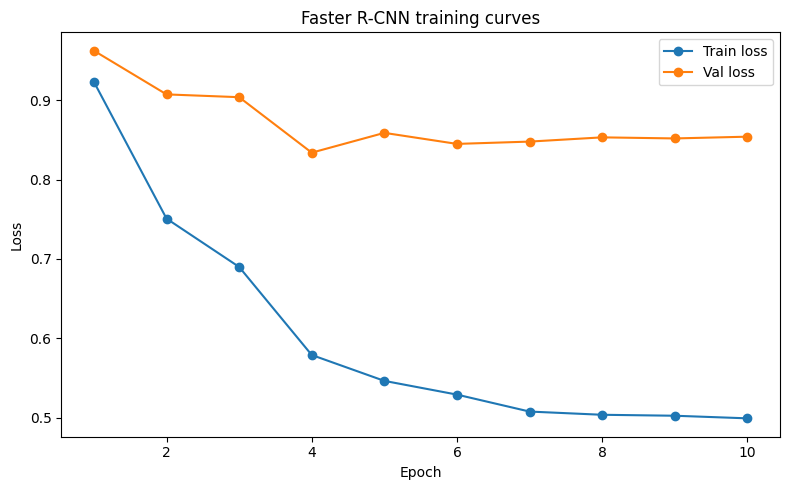

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], label="Train loss", marker="o")
ax.plot(history_df["epoch"], history_df["val_loss"], label="Val loss", marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Faster R-CNN training curves")
ax.legend()
plt.tight_layout()
plt.show()


## Test-Set mAP

Loads the best (lowest val-loss) checkpoint and computes COCO-style mAP on the held-out test
split — the same metric family the YOLO challenger should report, so the two models are
comparable head-to-head.


In [12]:
best_path = resolve_checkpoint(BEST_NAME)  # local copy if this session trained, else the Drive copy
assert best_path is not None, (
    f"No {BEST_NAME} in {LOCAL_CHECKPOINT_DIR} or {DRIVE_CHECKPOINT_DIR} - train at least one epoch first."
)
print(f"Evaluating checkpoint: {best_path}")

model.load_state_dict(torch.load(best_path, map_location=device))
model.to(device)
model.eval()

metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds = model(images)

        preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v for k, v in t.items() if k in ("boxes", "labels")} for t in targets]

        metric.update(preds, targets_cpu)

results = metric.compute()
print(f"mAP@[0.5:0.95]: {results['map']:.4f}")
print(f"mAP@0.5: {results['map_50']:.4f}")
print(f"mAP@0.75: {results['map_75']:.4f}")
print(f"mAR@100: {results['mar_100']:.4f}")


Evaluating checkpoint: /content/checkpoints/fasterrcnn/fasterrcnn_best.pt
mAP@[0.5:0.95]: 0.0785
mAP@0.5: 0.1594
mAP@0.75: 0.0675
mAR@100: 0.1444


### Per-Class AP


In [ ]:
per_class_ap = pd.DataFrame({
    "class": [CLASS_NAMES[i - 1] for i in results["classes"].tolist()],
    "AP@[0.5:0.95]": results["map_per_class"].tolist(),
})

# torchmetrics reports -1 for a class it could not evaluate (no ground-truth boxes AND no
# predictions for it anywhere in the test split). That means "not measured", not "an AP of -1",
# so those rows are separated out rather than sorted to the bottom of the table as though they
# were the worst scores - and they must never be averaged into a summary.
not_evaluated = per_class_ap[per_class_ap["AP@[0.5:0.95]"] < 0]
scored = per_class_ap[per_class_ap["AP@[0.5:0.95]"] >= 0].copy()
scored = scored.sort_values("AP@[0.5:0.95]", ascending=False).reset_index(drop=True)

detected = scored[scored["AP@[0.5:0.95]"] > 0]
print(f"{len(CLASS_NAMES)} classes in the taxonomy")
print(f"  {len(scored)} evaluated on the test split; {len(not_evaluated)} not evaluated "
      f"(absent from both predictions and ground truth)")
print(f"  {len(detected)} with AP > 0; {len(scored) - len(detected)} at AP = 0")
if len(detected):
    print(f"  among AP > 0: mean {detected['AP@[0.5:0.95]'].mean():.3f}, "
          f"median {detected['AP@[0.5:0.95]'].median():.3f}, "
          f"max {detected['AP@[0.5:0.95]'].max():.3f}")

# The headline mAP is held down mostly by the long tail of zeros, so show that shape explicitly
# rather than leaving a reader to infer it from a 127-row table.
bins = [-0.001, 0.0, 0.05, 0.15, 0.30, 1.0]
labels = ["AP = 0", "0 - 0.05", "0.05 - 0.15", "0.15 - 0.30", "> 0.30"]
print("\nAP distribution across evaluated classes:")
counts = pd.cut(scored["AP@[0.5:0.95]"], bins=bins, labels=labels).value_counts().sort_index()
for label, count in counts.items():
    print(f"  {label:>12}: {count:3d} classes")

if len(not_evaluated):
    print(f"\nNot evaluated ({len(not_evaluated)}): {', '.join(sorted(not_evaluated['class']))}")

scored.style.hide(axis="index").background_gradient(subset=["AP@[0.5:0.95]"], cmap="Blues")


## Sample Predictions

Ground truth in green, model predictions (score >= 0.5) in red, on a random sample of test
images.


In [ ]:
def draw_predictions(ax, image_tensor, target, prediction=None, score_thresh=0.5):
    img = image_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img)

    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), f"GT: {CLASS_NAMES[int(label) - 1]}", color="lime", fontsize=8)

    if prediction is not None:
        keep = prediction["scores"] >= score_thresh
        for box, label, score in zip(prediction["boxes"][keep], prediction["labels"][keep], prediction["scores"][keep]):
            x1, y1, x2, y2 = box.tolist()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y2 + 12, f"{CLASS_NAMES[int(label) - 1]}: {score:.2f}", color="red", fontsize=8)

    ax.axis("off")


model.eval()
sample_indices = random.sample(range(len(test_dataset)), min(6, len(test_dataset)))

# figsize/dpi kept modest deliberately: at (16, 10) this single figure embedded ~2.9 MB of PNG
# into the .ipynb, which dominated the file size in git. Raise dpi if you need a print-quality
# version for the report.
fig, axes = plt.subplots(2, 3, figsize=(14, 9), dpi=90)
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        img, target = test_dataset[idx]
        pred = model([img.to(device)])[0]
        pred = {k: v.cpu() for k, v in pred.items()}
        draw_predictions(ax, img, target, pred)

plt.suptitle("Green = ground truth, Red = predictions (score >= 0.5)")
plt.tight_layout()
plt.show()


## Key Takeaways

**Headline result.** On the held-out test split, using the lowest-val-loss checkpoint (epoch 4):

| Metric | Value |
|---|---|
| mAP@[0.5:0.95] | **0.0785** |
| mAP@0.5 | **0.1594** |
| mAP@0.75 | 0.0675 |
| mAR@100 | 0.1444 |

Evaluated on the same full `val`/`test` splits and the same unified taxonomy as the YOLO model, so
these are directly comparable head-to-head.

**The mAP is low, and the per-class table shows why.** Of the 148 classes in the taxonomy,
torchmetrics returned a per-class AP for 127; the other 21 never appeared in the test split at all.
Of those 127, **25 could not be evaluated** (reported as -1: no predictions *and* no ground truth),
leaving **102 genuinely evaluated — 56 with AP > 0 and 46 at exactly zero**. Among the classes the
model does detect, mean AP is 0.143, and the best is `bread` at 0.651, followed by `moringa leaves`
(0.377), `chicken` (0.350) and `orange` (0.350).
So this is not a uniformly weak detector: it is a detector that works on a minority of visually
distinctive, well-represented classes and fails completely on the long tail. That shape, not the
headline average, is the finding worth writing up, and it lines up with the class-imbalance results
in the EDA notebook.

**Three constraints bound this result, and should be stated explicitly rather than buried:**
1. *Data* — trained on a stratified 32.5% subset of the training split.
2. *Resolution* — 512/800 rather than torchvision's 800/1333, which costs most on small objects,
   exactly where a fine-grained ingredient task is hardest.
3. *Schedule* — validation loss stopped improving after epoch 4, and `StepLR(step_size=3,
   gamma=0.1)` had cut the learning rate to 1/100th of base by epoch 7, so only ~6 of 10 epochs did
   useful work.

Any mAP gap against YOLO therefore reflects *architecture plus compute budget plus an untuned
schedule*, not architecture alone. The honest framing is that this is a Colab-feasibility run, not a
tuned Faster R-CNN.

**Highest-value next steps, in order:**

- **Fix the LR schedule, and add early stopping on val loss.** `CosineAnnealingLR(optimizer,
  T_max=NUM_EPOCHS)` — or at minimum `StepLR(step_size=5)` — keeps a usable learning rate across
  the whole budget instead of dropping to 1/100th of base by epoch 7. Pair it with early stopping:
  epochs 5–10 cost ~1.4 hours and never beat epoch 4's val loss of 0.8339, and a patience-2 stop
  would have ended the run after epoch 6, recovering ~57 minutes of that. One implementation
  detail, since this loop resumes across sessions: the patience counter has to be saved into the
  checkpoint dict next to `best_val_loss`, or a resume silently resets it and training runs on.
  This costs no extra compute, so it comes before everything else here.
- **Raise `TRAIN_SUBSET_FRAC` toward 1.0** on a longer-lived runtime (Colab Pro L4/A100). This is
  the clean way to isolate the architecture effect from the compute budget, and it is also the most
  direct attack on the long tail. Budget for it first: at the measured ~10.2 img/s, the full
  23,317-image split is ~40 min/epoch against the subset's ~14, so 10 epochs is ~6.5 hours rather
  than the 2.4 this run took.
- **Restore the default resolution — `MIN_SIZE = 800` *and* `MAX_SIZE = 1333` — then re-measure**,
  to quantify how much of the small-object weakness is the resolution choice rather than the model.
  Raising `MIN_SIZE` alone does not do it: `GeneralizedRCNNTransform` caps the *longer* side at
  `MAX_SIZE`, so 800/800 would scale any non-square image to a shorter side well under 800 and land
  nearer the current setting than the default. Expect ~2.4x the pixels for a typical 4:3 image and
  roughly 2–2.5x the epoch time (~30–35 min/epoch on the current subset). Change this *or* the
  subset fraction in a given run, not both — together they are ~1.6 hours per epoch and ~16 hours
  for 10 epochs, and neither effect stays attributable.
- **Attack the long tail directly**, since that is where the headline mAP is actually lost: the 46
  evaluated classes at exactly zero AP contribute nothing but still divide the mean. Oversampling
  rare-class images in the training sampler (the stratification in the subset cell already computes
  the per-class counts needed for the weights) and reporting head vs. tail AP as separate numbers
  would both make the gain visible and stop a single average from hiding two very different
  behaviours.
- **Log per-image inference latency alongside mAP.** Two-stage detectors are typically slower than
  YOLO, which matters for a "challenger" framing if deployment cost is part of the evaluation.
  Measure it in `eval()` mode at batch size 1 with `torch.cuda.synchronize()` around each forward
  pass and the first few images discarded as warm-up, and report the `min_size`/`max_size` it was
  taken at — latency and mAP both move with resolution, so a latency number without one is not
  comparable to YOLO's.
